In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df_old = pd.read_csv(r"C:\Users\hp\Desktop\التنقيب على البيانات\web_\dubizzle_results1.csv")
df_new = pd.read_csv(r"C:\Users\hp\Desktop\التنقيب على البيانات\web_\dubizzle_results_3000.csv")

data_set = pd.concat([df_old, df_new], ignore_index=True).drop_duplicates(subset=["link"]).reset_index(drop=True)
data_set.head()

,title,price_egp,rooms,bathrooms,area_m2,link
0,شقة متشطبة جاهزة للسكن في Allegria اليجريا بدا...,7000000,4,4,198,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D8...
1,شقه للبيع استلام فورى في كمبوند سراي بسعر الكا...,5600000,3,2,164,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...
2,شقه للبيع في كمبوند سراي بسعر الكاش استلام فور...,5700000,3,2,169,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...
3,دوبلكس للبيع ياسمين ٦ التجمع الأول,16500000,5,5,440,https://www.dubizzle.com.eg/ad/%D8%AF%D9%88%D8...
4,للبيع شقة 175 متر في السياحية الشمالية الاولى ...,4285000,3,2,175,https://www.dubizzle.com.eg/ad/%D9%84%D9%84%D8...


## Do a preprocessing steps 

In [3]:
data_set.shape

(1349, 6)

In [4]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      1349 non-null   object
 1   price_egp  1349 non-null   int64 
 2   rooms      1349 non-null   int64 
 3   bathrooms  1349 non-null   int64 
 4   area_m2    1349 non-null   int64 
 5   link       1349 non-null   object
dtypes: int64(4), object(2)
memory usage: 63.4+ KB


In [5]:
data_set.duplicated(subset=["link"]).sum()

np.int64(0)

In [6]:
data_set.describe()

,price_egp,rooms,bathrooms,area_m2
count,1.349000e+03,1349.000000,1349.000000,1349.000000
mean,8.213227e+06,2.756857,2.424018,165.563380
std,5.544978e+06,0.802559,0.851540,67.786472
min,5.000000e+05,1.000000,1.000000,10.000000
25%,4.999800e+06,2.000000,2.000000,128.000000
50%,6.800000e+06,3.000000,2.000000,160.000000
75%,1.000000e+07,3.000000,3.000000,190.000000
max,9.000000e+07,10.000000,10.000000,840.000000


In [7]:
# لاحظنا إنه في صف فيه rooms = 10 وbathrooms = 10 بس area_m2 = 100 متر بس
# وهاد غير منطقي (يستحيل 10 غرف و10 حمامات بمساحة 100 متر)
# نتأكد هل هذا خطأ استخراج (Bad Data) أو رقم حقيقي
data_set[data_set["rooms"] == 10]   

,title,price_egp,rooms,bathrooms,area_m2,link
314,بأوفر لايقارن فيلاا 1100م استلام فوري متشطبه 1...,38000000,10,10,100,https://www.dubizzle.com.eg/ad/%D8%A8%D8%A3%D9...


In [8]:
# نتأكد كمان من أعلى سعر بالداتا (Outlier محتمل)
# وبعد ما راجعنا العنوان، طلع سعر حقيقي لدوبلكس فاخر 390 متر، فمش خطأ
data_set[data_set["price_egp"] == data_set["price_egp"].max()]

,title,price_egp,rooms,bathrooms,area_m2,link
881,شقة 600متر للبيع علي النيل مباشره بالزمالك,90000000,6,5,600,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D8...


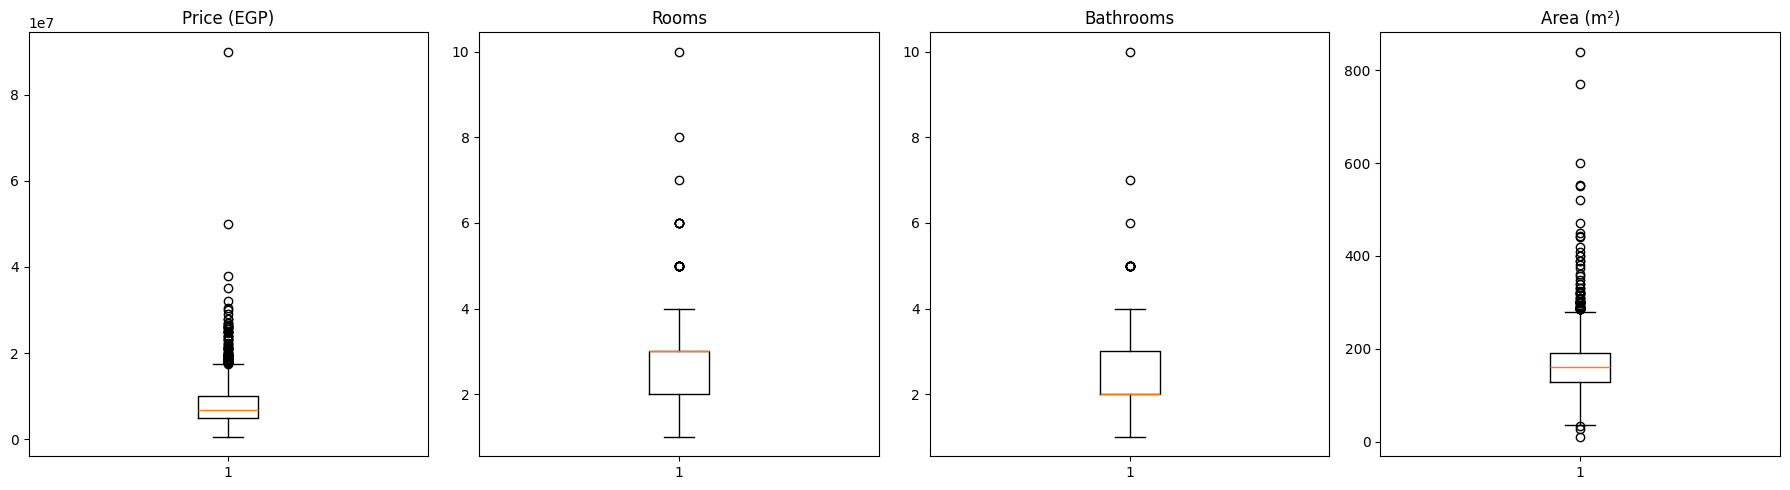

In [9]:
# نرسم Boxplot لكل عمود رقمي عشان نكتشف القيم الشاذة (Outliers) بصرياً
# قبل ما نقرر نحذفها أو لا
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].boxplot(data_set["price_egp"])
axes[0].set_title("Price (EGP)")

axes[1].boxplot(data_set["rooms"])
axes[1].set_title("Rooms")

axes[2].boxplot(data_set["bathrooms"])
axes[2].set_title("Bathrooms")

axes[3].boxplot(data_set["area_m2"])
axes[3].set_title("Area (m²)")

plt.tight_layout()
plt.show()

## Build a Linear Regression model using Sklearn library 

In [10]:
x = data_set[["rooms", "bathrooms", "area_m2"]]
y = data_set["price_egp"]

In [11]:
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(x, y, train_size=0.8, random_state=42)

In [12]:
#Normalization 
x_tr_norm = (x_tr - x_tr.mean()) / x_tr.std()
x_val_norm = (x_val - x_tr.mean()) / x_tr.std()

In [13]:
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(x_tr_norm, y_tr)
pred_1 = model_1.predict(x_val_norm)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val, pred_1)
r2 = r2_score(y_val, pred_1)

In [15]:
print(f"MAE: {mae:,.2f}")
print(f"R²: {r2:.4f}")

MAE: 3,090,033.50
R²: 0.2752


In [16]:
data_set[["price_egp", "rooms", "bathrooms", "area_m2"]].corr()

,price_egp,rooms,bathrooms,area_m2
price_egp,1.000000,0.383512,0.499494,0.489092
rooms,0.383512,1.000000,0.686117,0.708978
bathrooms,0.499494,0.686117,1.000000,0.616444
area_m2,0.489092,0.708978,0.616444,1.000000


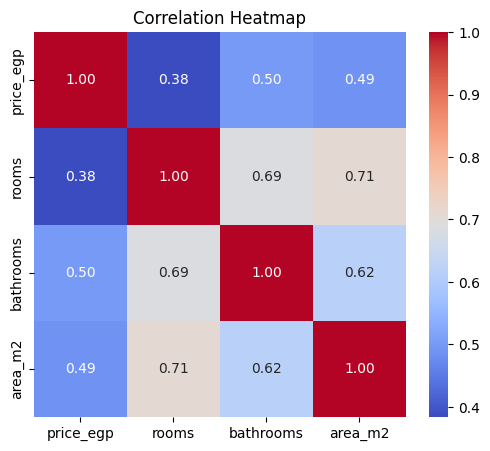

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(data_set[["price_egp", "rooms", "bathrooms", "area_m2"]].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
data_set["is_compound"] = data_set["title"].str.contains("كمبوند", na=False).astype(int)
data_set["is_compound"].value_counts()

is_compound
0    1026
1     323
Name: count, dtype: int64

In [19]:
# هنا جربت لو بدي اكتب بالعربي والانجليزي هل بيفرق ولا لأ
data_set["is_compound"] = (
    data_set["title"].str.contains("كمبوند", na=False) |
    data_set["title"].str.contains("compound", case=False, na=False)
).astype(int)

In [20]:
data_set["is_compound"].value_counts()

is_compound
0    1016
1     333
Name: count, dtype: int64

In [21]:
data_set["is_duplex"] = (
    data_set["title"].str.contains("دوبلكس", na=False) |
    data_set["title"].str.contains("duplex", case=False, na=False)
).astype(int)
data_set["is_duplex"].value_counts()

is_duplex
0    1286
1      63
Name: count, dtype: int64

In [22]:
data_set["is_penthouse"] = (
    data_set["title"].str.contains("بنتهاوس", na=False) |
    data_set["title"].str.contains("penthouse", case=False, na=False)
).astype(int)
data_set["is_penthouse"].value_counts()

is_penthouse
0    1297
1      52
Name: count, dtype: int64

In [23]:
data_set["is_finished"] = (
    data_set["title"].str.contains("متشطب", na=False) |
    data_set["title"].str.contains("finished", case=False, na=False)
).astype(int)

In [24]:
data_set["is_ready"] = (
    data_set["title"].str.contains("استلام فوري", na=False) |
    data_set["title"].str.contains("استلام فورى", na=False)
).astype(int)

In [25]:
data_set["has_view"] = (
    data_set["title"].str.contains("فيو", na=False) |
    data_set["title"].str.contains("view", case=False, na=False)
).astype(int)

In [26]:
data_set["is_luxury"] = (
    data_set["title"].str.contains("لوكس", na=False) |
    data_set["title"].str.contains("luxury", case=False, na=False)
).astype(int)

In [27]:
data_set["is_cash"] = data_set["title"].str.contains("كاش", na=False).astype(int)

In [28]:
data_set["has_discount"] = data_set["title"].str.contains("خصم", na=False).astype(int)

In [29]:
data_set["is_installment"] = (
    data_set["title"].str.contains("اقساط", na=False) |
    data_set["title"].str.contains("تقسيط", na=False) |
    data_set["title"].str.contains("مقدم", na=False)
).astype(int)

In [30]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           1349 non-null   object
 1   price_egp       1349 non-null   int64 
 2   rooms           1349 non-null   int64 
 3   bathrooms       1349 non-null   int64 
 4   area_m2         1349 non-null   int64 
 5   link            1349 non-null   object
 6   is_compound     1349 non-null   int64 
 7   is_duplex       1349 non-null   int64 
 8   is_penthouse    1349 non-null   int64 
 9   is_finished     1349 non-null   int64 
 10  is_ready        1349 non-null   int64 
 11  has_view        1349 non-null   int64 
 12  is_luxury       1349 non-null   int64 
 13  is_cash         1349 non-null   int64 
 14  has_discount    1349 non-null   int64 
 15  is_installment  1349 non-null   int64 
dtypes: int64(14), object(2)
memory usage: 168.8+ KB


In [31]:
# 1. نبدأ بقيمة افتراضية
data_set["area"] = "unspecified"

# 2. نعبي كل منطقة (بالانجليزي مباشرة)
data_set.loc[data_set["title"].str.contains("الشروق", na=False), "area"] = "El_Shorouk"
data_set.loc[data_set["title"].str.contains("مدينتي", na=False), "area"] = "Madinaty"
data_set.loc[data_set["title"].str.contains("الشيخ زايد|زايد", na=False), "area"] = "Sheikh_Zayed"
data_set.loc[data_set["title"].str.contains("القاهرة الجديدة|القاهره الجديده", na=False), "area"] = "New_Cairo"
data_set.loc[data_set["title"].str.contains("التجمع الخامس", na=False), "area"] = "Fifth_Settlement"

# 3. نشوف التوزيع قبل ما نحول لـ dummies
print(data_set["area"].value_counts())

area_dummies = pd.get_dummies(data_set["area"], prefix="area").astype(int)
data_set = pd.concat([data_set, area_dummies], axis=1)

area
unspecified         809
Fifth_Settlement    271
Madinaty             95
New_Cairo            90
El_Shorouk           46
Sheikh_Zayed         38
Name: count, dtype: int64


In [32]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  1349 non-null   object
 1   price_egp              1349 non-null   int64 
 2   rooms                  1349 non-null   int64 
 3   bathrooms              1349 non-null   int64 
 4   area_m2                1349 non-null   int64 
 5   link                   1349 non-null   object
 6   is_compound            1349 non-null   int64 
 7   is_duplex              1349 non-null   int64 
 8   is_penthouse           1349 non-null   int64 
 9   is_finished            1349 non-null   int64 
 10  is_ready               1349 non-null   int64 
 11  has_view               1349 non-null   int64 
 12  is_luxury              1349 non-null   int64 
 13  is_cash                1349 non-null   int64 
 14  has_discount           1349 non-null   int64 
 15  is_installment       

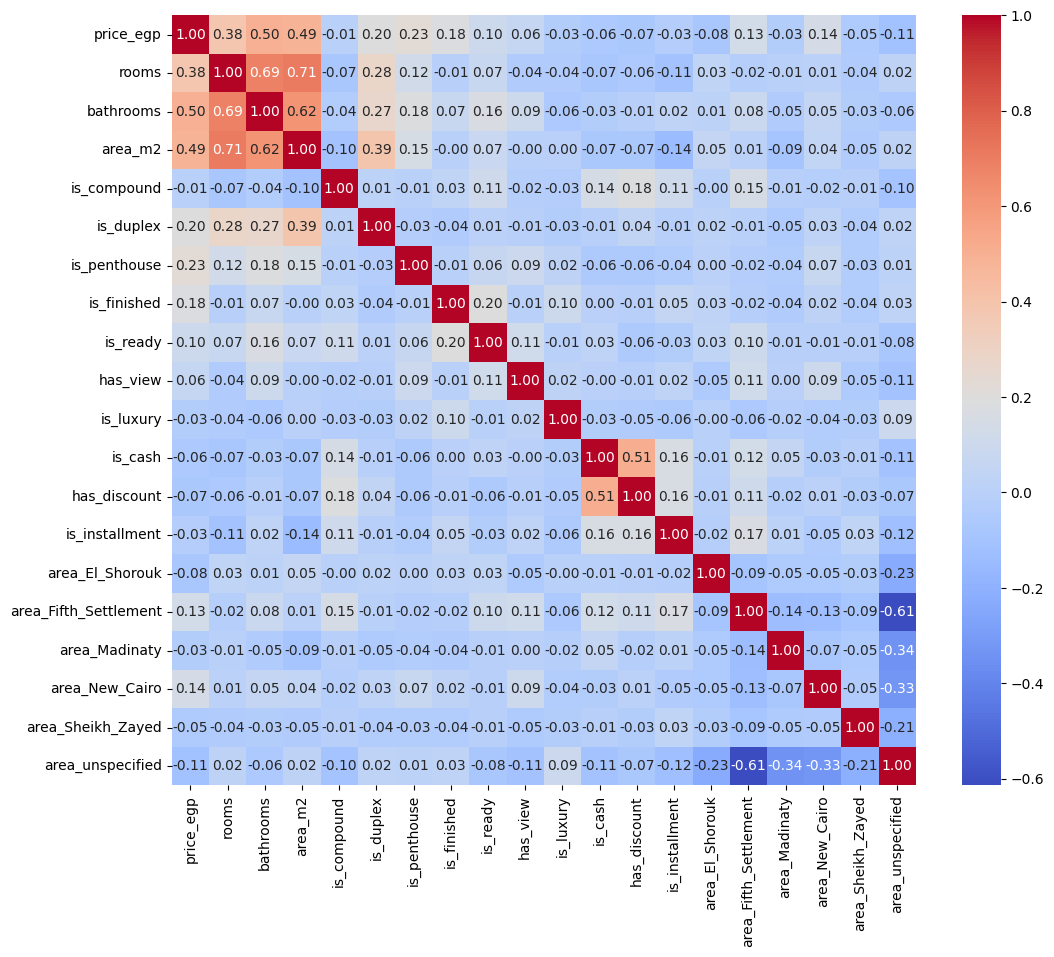

In [33]:
plt.figure(figsize=(12, 10))
sns.heatmap(data_set.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [34]:
data_set.head()

,title,price_egp,rooms,bathrooms,area_m2,link,is_compound,is_duplex,is_penthouse,is_finished,...,is_cash,has_discount,is_installment,area,area_El_Shorouk,area_Fifth_Settlement,area_Madinaty,area_New_Cairo,area_Sheikh_Zayed,area_unspecified
0,شقة متشطبة جاهزة للسكن في Allegria اليجريا بدا...,7000000,4,4,198,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D8...,0,0,0,1,...,0,0,0,unspecified,0,0,0,0,0,1
1,شقه للبيع استلام فورى في كمبوند سراي بسعر الكا...,5600000,3,2,164,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...,1,0,0,0,...,1,1,1,New_Cairo,0,0,0,1,0,0
2,شقه للبيع في كمبوند سراي بسعر الكاش استلام فور...,5700000,3,2,169,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...,1,0,0,0,...,1,1,1,New_Cairo,0,0,0,1,0,0
3,دوبلكس للبيع ياسمين ٦ التجمع الأول,16500000,5,5,440,https://www.dubizzle.com.eg/ad/%D8%AF%D9%88%D8...,0,1,0,0,...,0,0,0,unspecified,0,0,0,0,0,1
4,للبيع شقة 175 متر في السياحية الشمالية الاولى ...,4285000,3,2,175,https://www.dubizzle.com.eg/ad/%D9%84%D9%84%D8...,0,0,0,0,...,0,0,0,unspecified,0,0,0,0,0,1


In [35]:
# حذف الأعمدة غير المطلوبة مع عمود السعر من x2
x2 = data_set.drop(columns=["title", "link", "price_egp", "area"])
y2 = data_set["price_egp"]

x2_tr, x2_val, y2_tr, y2_val = train_test_split(x2, y2, train_size=0.8, random_state=42)

In [36]:
#Normalization 
x2_tr_norm = (x2_tr - x2_tr.mean()) / x2_tr.std()
x2_val_norm = (x2_val - x2_tr.mean()) / x2_tr.std()

In [37]:
model_2 = LinearRegression()
model_2.fit(x2_tr_norm, y2_tr)
pred_2 = model_2.predict(x2_val_norm)

In [38]:
mae_2 = mean_absolute_error(y2_val, pred_2)
r2_2 = r2_score(y2_val, pred_2)
print(f"MAE: {mae_2:,.2f}")
print(f"R²: {r2_2:.4f}")

MAE: 2,779,725.85
R²: 0.4167
